<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/ptq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Post-Training Quantization (PTQ)

Post-Training Quantization (PTQ) converts a pre-trained FP model to lower precision without retraining. This is the most practical approach for LLMs where fine-tuning is expensive or impossible.

I build production PTQ systems:
- **Weight-only PTQ**: Quantize weights, keep activations in FP16
- **Weight + Activation PTQ**: Full INT8 inference
- **Calibration strategies**: MinMax, Percentile, MSE-optimal, Entropy
- **Smooth Quantization**: Handle outliers in activations
- **Layer-wise sensitivity**: Identify which layers to skip


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from transformers import AutoModelForCausalLM, AutoTokenizer, GPT2LMHeadModel
from typing import Optional, Tuple, Dict, List, Union, Callable, Iterator
from dataclasses import dataclass, field
from enum import Enum
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import copy
import time
import gc
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*60)
print("Day 2: Post-Training Quantization (PTQ)")
print("="*60)
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Day 2: Post-Training Quantization (PTQ)
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
@dataclass
class PTQConfig:
    """PTQ configuration."""
    # Weight quantization
    w_bits: int = 8
    w_symmetric: bool = True
    w_per_channel: bool = True
    w_group_size: Optional[int] = None  # None = per-channel/tensor

    # Activation quantization
    a_bits: int = 8
    a_symmetric: bool = True
    a_per_token: bool = False  # Per-token vs per-tensor

    # Calibration
    calib_method: str = 'minmax'  # minmax, percentile, mse, entropy
    calib_samples: int = 128
    percentile: float = 99.99

    # Layers
    skip_layers: List[str] = field(default_factory=lambda: ['lm_head'])

    def __repr__(self):
        return (f"PTQConfig(W{self.w_bits}A{self.a_bits}, "
                f"w_sym={self.w_symmetric}, w_pc={self.w_per_channel}, "
                f"calib={self.calib_method})")

 Weight-Only PTQ

Most common for LLMs: quantize weights to INT4/INT8, keep activations in FP16.
This gives memory savings while maintaining compute precision.

In [3]:
class WeightQuantizer:
    """
    Weight-only quantization with multiple schemes.

    Supports:
    - Per-tensor / per-channel / per-group
    - Symmetric / asymmetric
    - Round-to-nearest (RTN)
    """

    def __init__(self, config: PTQConfig):
        self.config = config
        self.bits = config.w_bits

        if config.w_symmetric:
            self.qmin = -(2 ** (self.bits - 1))
            self.qmax = 2 ** (self.bits - 1) - 1
        else:
            self.qmin = 0
            self.qmax = 2 ** self.bits - 1

    def quantize_tensor(self, weight: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        """Quantize weight tensor (per-tensor)."""
        if self.config.w_symmetric:
            scale = weight.abs().max() / self.qmax
            scale = torch.clamp(scale, min=1e-8)
            zero_point = torch.tensor(0.0)
        else:
            wmin, wmax = weight.min(), weight.max()
            scale = (wmax - wmin) / (self.qmax - self.qmin)
            scale = torch.clamp(scale, min=1e-8)
            zero_point = torch.round(self.qmin - wmin / scale)

        q_weight = torch.round(weight / scale + zero_point)
        q_weight = torch.clamp(q_weight, self.qmin, self.qmax)

        return q_weight, scale, zero_point

    def quantize_per_channel(self, weight: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        """Quantize weight tensor (per output channel)."""
        # weight shape: (out_features, in_features)
        out_features = weight.shape[0]

        if self.config.w_symmetric:
            # Max abs per row
            amax = weight.abs().amax(dim=1, keepdim=True)
            scale = amax / self.qmax
            scale = torch.clamp(scale, min=1e-8)
            zero_point = torch.zeros(out_features, 1, device=weight.device)
        else:
            wmin = weight.amin(dim=1, keepdim=True)
            wmax = weight.amax(dim=1, keepdim=True)
            scale = (wmax - wmin) / (self.qmax - self.qmin)
            scale = torch.clamp(scale, min=1e-8)
            zero_point = torch.round(self.qmin - wmin / scale)

        q_weight = torch.round(weight / scale + zero_point)
        q_weight = torch.clamp(q_weight, self.qmin, self.qmax)

        return q_weight, scale.squeeze(), zero_point.squeeze()

    def quantize_per_group(self, weight: Tensor,
                           group_size: int) -> Tuple[Tensor, Tensor, Tensor]:
        """Quantize weight tensor (per group)."""
        out_features, in_features = weight.shape

        # Pad if necessary
        if in_features % group_size != 0:
            pad = group_size - (in_features % group_size)
            weight = F.pad(weight, (0, pad))
            in_features = weight.shape[1]

        # Reshape: (out, in) -> (out, num_groups, group_size)
        num_groups = in_features // group_size
        weight_grouped = weight.view(out_features, num_groups, group_size)

        if self.config.w_symmetric:
            amax = weight_grouped.abs().amax(dim=2, keepdim=True)
            scale = amax / self.qmax
            scale = torch.clamp(scale, min=1e-8)
            zero_point = torch.zeros_like(scale)
        else:
            wmin = weight_grouped.amin(dim=2, keepdim=True)
            wmax = weight_grouped.amax(dim=2, keepdim=True)
            scale = (wmax - wmin) / (self.qmax - self.qmin)
            scale = torch.clamp(scale, min=1e-8)
            zero_point = torch.round(self.qmin - wmin / scale)

        q_weight = torch.round(weight_grouped / scale + zero_point)
        q_weight = torch.clamp(q_weight, self.qmin, self.qmax)

        return q_weight, scale.squeeze(-1), zero_point.squeeze(-1)

    def quantize(self, weight: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        """Main quantization entry point."""
        if self.config.w_group_size:
            return self.quantize_per_group(weight, self.config.w_group_size)
        elif self.config.w_per_channel:
            return self.quantize_per_channel(weight)
        else:
            return self.quantize_tensor(weight)

    def dequantize(self, q_weight: Tensor, scale: Tensor,
                   zero_point: Tensor, original_shape: Tuple) -> Tensor:
        """Dequantize back to float."""
        if self.config.w_group_size:
            # Grouped: (out, groups, group_size), scale: (out, groups)
            scale = scale.unsqueeze(-1)
            zero_point = zero_point.unsqueeze(-1)
            weight = (q_weight.float() - zero_point) * scale
            weight = weight.view(original_shape[0], -1)
            weight = weight[:, :original_shape[1]]  # Remove padding
        elif self.config.w_per_channel:
            # Per-channel: scale is (out_features,)
            weight = (q_weight.float() - zero_point.unsqueeze(1)) * scale.unsqueeze(1)
        else:
            # Per-tensor
            weight = (q_weight.float() - zero_point) * scale

        return weight

In [4]:
# Test weight quantization schemes

print("Weight Quantization Schemes Comparison")
print("=" * 60)

# Create test weight matrix
torch.manual_seed(42)
weight = torch.randn(4096, 4096) * 0.02

# Add some outliers (common in LLMs)
weight[0, 0] = 0.5
weight[100, 200] = -0.4

configs = [
    PTQConfig(w_bits=8, w_symmetric=True, w_per_channel=False),
    PTQConfig(w_bits=8, w_symmetric=True, w_per_channel=True),
    PTQConfig(w_bits=4, w_symmetric=True, w_per_channel=True),
    PTQConfig(w_bits=4, w_symmetric=True, w_per_channel=True, w_group_size=128),
    PTQConfig(w_bits=4, w_symmetric=True, w_per_channel=True, w_group_size=64),
]

print(f"\n{'Config':<45} {'MAE':>10} {'Max Err':>10} {'SQNR':>10}")
print("-" * 75)

for config in configs:
    quantizer = WeightQuantizer(config)
    q_w, scale, zp = quantizer.quantize(weight)
    w_dq = quantizer.dequantize(q_w, scale, zp, weight.shape)

    error = weight - w_dq
    mae = error.abs().mean().item()
    max_err = error.abs().max().item()

    # Signal-to-Quantization-Noise Ratio
    signal_power = (weight ** 2).mean()
    noise_power = (error ** 2).mean()
    sqnr = 10 * torch.log10(signal_power / noise_power).item()

    desc = f"W{config.w_bits}"
    if config.w_group_size:
        desc += f"-g{config.w_group_size}"
    elif config.w_per_channel:
        desc += "-perchannel"
    else:
        desc += "-pertensor"

    print(f"{desc:<45} {mae:>10.6f} {max_err:>10.6f} {sqnr:>9.1f}dB")

Weight Quantization Schemes Comparison

Config                                               MAE    Max Err       SQNR
---------------------------------------------------------------------------
W8-pertensor                                    0.000984   0.001969      24.9dB
W8-perchannel                                   0.000150   0.001968      41.2dB
W4-perchannel                                   0.002718   0.035685      16.0dB
W4-g128                                         0.002004   0.034537      18.6dB
W4-g64                                          0.001826   0.034537      19.4dB


 Activation Quantization

For full INT8 inference, we also quantize activations. This is harder because:
1. Activations are dynamic (data-dependent)
2. LLMs have **outliers** in activations (certain channels have 100x larger values)

In [5]:
class ActivationQuantizer:
    """
    Activation quantization with calibration.

    Static: Scales determined during calibration
    Dynamic: Scales computed per forward pass
    """

    def __init__(self, config: PTQConfig):
        self.config = config
        self.bits = config.a_bits

        if config.a_symmetric:
            self.qmin = -(2 ** (self.bits - 1))
            self.qmax = 2 ** (self.bits - 1) - 1
        else:
            self.qmin = 0
            self.qmax = 2 ** self.bits - 1

        # Calibration statistics
        self.calibrated = False
        self.scale = None
        self.zero_point = None

    def calibrate(self, activations: List[Tensor]):
        """
        Calibrate quantization parameters from sample activations.
        """
        all_vals = torch.cat([a.flatten() for a in activations])

        if self.config.calib_method == 'minmax':
            self._calibrate_minmax(all_vals)
        elif self.config.calib_method == 'percentile':
            self._calibrate_percentile(all_vals)
        elif self.config.calib_method == 'mse':
            self._calibrate_mse(all_vals)
        else:
            self._calibrate_minmax(all_vals)

        self.calibrated = True

    def _calibrate_minmax(self, vals: Tensor):
        """MinMax calibration."""
        if self.config.a_symmetric:
            amax = vals.abs().max()
            self.scale = amax / self.qmax
            self.zero_point = torch.tensor(0.0)
        else:
            vmin, vmax = vals.min(), vals.max()
            self.scale = (vmax - vmin) / (self.qmax - self.qmin)
            self.zero_point = torch.round(self.qmin - vmin / self.scale)

        self.scale = torch.clamp(self.scale, min=1e-8)

    def _calibrate_percentile(self, vals: Tensor):
        """Percentile calibration - clips outliers."""
        pct = self.config.percentile / 100.0

        if self.config.a_symmetric:
            amax = torch.quantile(vals.abs(), pct)
            self.scale = amax / self.qmax
            self.zero_point = torch.tensor(0.0)
        else:
            vmin = torch.quantile(vals, 1 - pct)
            vmax = torch.quantile(vals, pct)
            self.scale = (vmax - vmin) / (self.qmax - self.qmin)
            self.zero_point = torch.round(self.qmin - vmin / self.scale)

        self.scale = torch.clamp(self.scale, min=1e-8)

    def _calibrate_mse(self, vals: Tensor):
        """MSE-optimal calibration - find scale that minimizes reconstruction error."""
        best_scale = None
        best_mse = float('inf')

        amax = vals.abs().max()

        # Search over different clipping factors
        for clip_ratio in np.linspace(0.5, 1.0, 20):
            clip_val = amax * clip_ratio
            scale = clip_val / self.qmax

            # Simulate quantization
            q = torch.round(vals / scale).clamp(self.qmin, self.qmax)
            dq = q * scale

            mse = ((vals - dq) ** 2).mean()

            if mse < best_mse:
                best_mse = mse
                best_scale = scale

        self.scale = best_scale
        self.zero_point = torch.tensor(0.0)

    def quantize(self, x: Tensor, dynamic: bool = False) -> Tuple[Tensor, Tensor, Tensor]:
        """Quantize activations."""
        if dynamic:
            # Compute scale on-the-fly
            if self.config.a_per_token:
                # Per-token: scale per (batch, seq) position
                amax = x.abs().amax(dim=-1, keepdim=True)
            else:
                amax = x.abs().amax()

            scale = torch.clamp(amax / self.qmax, min=1e-8)
            zero_point = torch.tensor(0.0, device=x.device)
        else:
            if not self.calibrated:
                raise ValueError("Must calibrate before static quantization")
            scale = self.scale.to(x.device)
            zero_point = self.zero_point.to(x.device)

        q = torch.round(x / scale + zero_point)
        q = torch.clamp(q, self.qmin, self.qmax)

        return q, scale, zero_point

    def dequantize(self, q: Tensor, scale: Tensor, zero_point: Tensor) -> Tensor:
        return (q.float() - zero_point) * scale

In [6]:
# Test activation quantization with different calibration methods

print("\nActivation Quantization Calibration Methods")
print("=" * 60)

# Simulate LLM activations with outliers
torch.manual_seed(42)
activations = torch.randn(1000, 768) * 0.5
# Add outlier channels (common in transformers)
activations[:, 0] *= 50  # 50x outlier
activations[:, 100] *= 30

print(f"Activation stats: mean={activations.mean():.4f}, std={activations.std():.4f}")
print(f"                  min={activations.min():.4f}, max={activations.max():.4f}")
print(f"                  Channel 0 max={activations[:, 0].abs().max():.4f}")

calib_methods = ['minmax', 'percentile', 'mse']

print(f"\n{'Method':<15} {'Scale':>10} {'MAE':>10} {'Max Err':>10} {'SQNR':>10}")
print("-" * 60)

for method in calib_methods:
    config = PTQConfig(a_bits=8, calib_method=method, percentile=99.9)
    quantizer = ActivationQuantizer(config)

    # Calibrate
    quantizer.calibrate([activations])

    # Quantize
    q, scale, zp = quantizer.quantize(activations)
    dq = quantizer.dequantize(q, scale, zp)

    error = activations - dq
    mae = error.abs().mean().item()
    max_err = error.abs().max().item()

    signal_power = (activations ** 2).mean()
    noise_power = (error ** 2).mean()
    sqnr = 10 * torch.log10(signal_power / noise_power).item()

    print(f"{method:<15} {scale.item():>10.4f} {mae:>10.4f} {max_err:>10.4f} {sqnr:>9.1f}dB")


Activation Quantization Calibration Methods
Activation stats: mean=-0.0012, std=1.1934
                  min=-101.3699, max=87.2832
                  Channel 0 max=101.3699

Method               Scale        MAE    Max Err       SQNR
------------------------------------------------------------
minmax              0.7982     0.1994     0.3991      14.3dB
percentile          0.1344     0.0462    84.1658       6.7dB
mse                 0.4831     0.1210    39.5313      17.6dB


 Advanced Calibration

For production PTQ, we need calibration that handles real model behavior.

In [7]:
class CalibrationCollector:
    """
    Collect activation statistics during calibration forward passes.
    """

    def __init__(self):
        self.inputs: Dict[str, List[Tensor]] = defaultdict(list)
        self.outputs: Dict[str, List[Tensor]] = defaultdict(list)
        self.hooks = []

    def _make_hook(self, name: str):
        def hook(module, inp, out):
            if isinstance(inp, tuple):
                inp = inp[0]
            if isinstance(out, tuple):
                out = out[0]

            # Store CPU copy to save memory
            self.inputs[name].append(inp.detach().cpu())
            self.outputs[name].append(out.detach().cpu())

        return hook

    def register_hooks(self, model: nn.Module, target_layers: List[str] = None):
        """Register hooks on target layers."""
        for name, module in model.named_modules():
            if isinstance(module, nn.Linear):
                if target_layers is None or any(t in name for t in target_layers):
                    hook = module.register_forward_hook(self._make_hook(name))
                    self.hooks.append(hook)

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []

    def get_input_stats(self, layer_name: str) -> Dict:
        """Get statistics for a layer's inputs."""
        if layer_name not in self.inputs:
            return {}

        all_inputs = torch.cat([x.flatten() for x in self.inputs[layer_name]])

        return {
            'min': all_inputs.min().item(),
            'max': all_inputs.max().item(),
            'mean': all_inputs.mean().item(),
            'std': all_inputs.std().item(),
            'absmax': all_inputs.abs().max().item(),
            'percentile_99': torch.quantile(all_inputs.abs(), 0.99).item(),
            'percentile_999': torch.quantile(all_inputs.abs(), 0.999).item(),
        }

    def analyze_outliers(self, layer_name: str) -> Dict:
        """Analyze outlier channels in activations."""
        if layer_name not in self.inputs:
            return {}

        # Stack all activations
        # Assuming shape (batch, seq, hidden) or (batch, hidden)
        acts = torch.cat(self.inputs[layer_name], dim=0)

        if acts.dim() == 3:
            # (batch, seq, hidden) -> flatten batch and seq
            acts = acts.view(-1, acts.size(-1))

        # Per-channel max
        channel_max = acts.abs().amax(dim=0)
        global_max = channel_max.max()

        # Outlier channels: max > 10x median
        median_max = channel_max.median()
        outlier_mask = channel_max > 10 * median_max
        outlier_indices = torch.where(outlier_mask)[0].tolist()

        return {
            'num_outlier_channels': len(outlier_indices),
            'outlier_indices': outlier_indices[:10],  # First 10
            'max_outlier_ratio': (channel_max.max() / median_max).item(),
            'channel_max_std': channel_max.std().item(),
        }

In [12]:
# Load model for calibration testing

print("\nLoading GPT-2 for Calibration")
print("=" * 50)

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

# Set pad_token for the tokenizer
tokenizer.pad_token = tokenizer.eos_token

# Calibration data
calib_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Machine learning is transforming the world of technology.",
    "In recent years, large language models have become increasingly powerful.",
    "Python is a versatile programming language used for many applications.",
    "The transformer architecture revolutionized natural language processing.",
    "Deep learning requires large amounts of data and computational power.",
    "Artificial intelligence is being applied across many industries.",
    "Neural networks can learn complex patterns from data.",
]

print(f"Model: {model_name}")
print(f"Calibration samples: {len(calib_texts)}")


Loading GPT-2 for Calibration


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: gpt2
Calibration samples: 8


In [13]:
import torch.nn as nn



# Run calibration

print("\nRunning Calibration...")
print("=" * 50)

collector = CalibrationCollector()
collector.register_hooks(model)

# Forward pass on calibration data
with torch.no_grad():
    for text in calib_texts:
        inputs = tokenizer(text, return_tensors="pt", padding='max_length', truncation=True, max_length=512)
        _ = model(**inputs)

collector.remove_hooks()

# Analyze collected statistics
print(f"\nCollected activations for {len(collector.inputs)} layers")

# Show stats for a few layers
print(f"\n{'Layer':<40} {'Min':>10} {'Max':>10} {'AbsMax':>10} {'P99':>10}")
print("-" * 85)

for name in list(collector.inputs.keys())[:6]:
    stats = collector.get_input_stats(name)
    short_name = name.split('.')[-2] + '.' + name.split('.')[-1] if '.' in name else name
    print(f"{short_name:<40} {stats['min']:>10.4f} {stats['max']:>10.4f} "
          f"{stats['absmax']:>10.4f} {stats['percentile_99']:>10.4f}")


Running Calibration...

Collected activations for 1 layers

Layer                                           Min        Max     AbsMax        P99
-------------------------------------------------------------------------------------
lm_head                                   -115.8708   273.7929   273.7929     8.9951


In [14]:
# Analyze outliers

print("\nOutlier Analysis")
print("=" * 50)

print(f"\n{'Layer':<40} {'Outlier Ch':>12} {'Max Ratio':>12}")
print("-" * 65)

for name in list(collector.inputs.keys())[:8]:
    outliers = collector.analyze_outliers(name)
    if outliers:
        short_name = name.split('.')[-2] + '.' + name.split('.')[-1] if '.' in name else name
        print(f"{short_name:<40} {outliers['num_outlier_channels']:>12} "
              f"{outliers['max_outlier_ratio']:>11.1f}x")


Outlier Analysis

Layer                                      Outlier Ch    Max Ratio
-----------------------------------------------------------------
lm_head                                            12       254.7x


 Smooth Quantization

**Problem**: LLM activations have outlier channels that are hard to quantize.

**Solution**: Migrate the quantization difficulty from activations to weights by applying a smoothing factor.

```
Y = X @ W
Y = (X / s) @ (s * W)  # Mathematically equivalent
Y = X_smooth @ W_smooth
```

By dividing X by s (smoothing activations) and multiplying W by s, we balance the difficulty.

In [15]:
class SmoothQuantizer:
    """
    Smooth Quantization implementation.

    From: "SmoothQuant: Accurate and Efficient Post-Training Quantization
           for Large Language Models" (Xiao et al., 2022)

    Key idea:
    - Find per-channel smoothing factor s
    - s = max(|X|)^α / max(|W|)^(1-α)
    - Apply X_new = X / s, W_new = W * s
    - This balances quantization difficulty between X and W
    """

    def __init__(self, alpha: float = 0.5):
        self.alpha = alpha  # Migration strength: 0=all to W, 1=all to X
        self.smooth_scales: Dict[str, Tensor] = {}

    def compute_smooth_scale(self, act_max: Tensor, weight: Tensor) -> Tensor:
        """
        Compute smoothing scale for a layer.

        Args:
            act_max: Per-channel max of activations (input features)
            weight: Weight matrix (out_features, in_features)
        """
        # Weight max per input channel
        weight_max = weight.abs().amax(dim=0)  # (in_features,)

        # Compute scale
        # s = act_max^alpha / weight_max^(1-alpha)
        scale = (act_max.pow(self.alpha) /
                 weight_max.clamp(min=1e-8).pow(1 - self.alpha))

        return scale

    def smooth_layer(self, layer_name: str, weight: Tensor,
                     act_max: Tensor) -> Tensor:
        """
        Apply smoothing to a layer's weights.

        Returns smoothed weights. Activations should be divided by scale.
        """
        scale = self.compute_smooth_scale(act_max, weight)
        self.smooth_scales[layer_name] = scale

        # Smooth weights: W_new = W * s
        # scale is (in_features,), weight is (out, in)
        smoothed_weight = weight * scale.unsqueeze(0)

        return smoothed_weight

    def smooth_activation(self, x: Tensor, layer_name: str) -> Tensor:
        """Apply smoothing to activations: X_new = X / s."""
        if layer_name not in self.smooth_scales:
            return x

        scale = self.smooth_scales[layer_name].to(x.device)
        return x / scale

    def analyze_smoothing_effect(self, weight: Tensor,
                                  act_max: Tensor) -> Dict:
        """Analyze the effect of smoothing."""
        # Before smoothing
        act_range_before = act_max.max() / act_max.min()
        weight_channel_max = weight.abs().amax(dim=0)
        weight_range_before = weight_channel_max.max() / weight_channel_max.min()

        # After smoothing
        scale = self.compute_smooth_scale(act_max, weight)
        smoothed_weight = weight * scale.unsqueeze(0)
        smoothed_act_max = act_max / scale

        act_range_after = smoothed_act_max.max() / smoothed_act_max.min()
        smoothed_weight_max = smoothed_weight.abs().amax(dim=0)
        weight_range_after = smoothed_weight_max.max() / smoothed_weight_max.min()

        return {
            'act_range_before': act_range_before.item(),
            'act_range_after': act_range_after.item(),
            'weight_range_before': weight_range_before.item(),
            'weight_range_after': weight_range_after.item(),
            'act_improvement': act_range_before.item() / act_range_after.item(),
        }

In [16]:
# Test smooth quantization

print("\nSmooth Quantization Test")
print("=" * 60)

# Simulate LLM layer with outliers
torch.manual_seed(42)
in_features, out_features = 768, 768

weight = torch.randn(out_features, in_features) * 0.02

# Activations with outlier channels
act_max = torch.ones(in_features) * 0.5
act_max[0] = 50.0  # 100x outlier
act_max[100] = 30.0  # 60x outlier
act_max[200] = 20.0

print("Before Smoothing:")
print(f"  Activation range: {act_max.min():.2f} - {act_max.max():.2f} ({act_max.max()/act_max.min():.1f}x)")
print(f"  Weight channel range: {weight.abs().amax(dim=0).min():.4f} - {weight.abs().amax(dim=0).max():.4f}")

# Try different alpha values
print(f"\n{'Alpha':<10} {'Act Range After':>18} {'Weight Range After':>20} {'Act Improvement':>18}")
print("-" * 70)

for alpha in [0.25, 0.5, 0.75, 1.0]:
    sq = SmoothQuantizer(alpha=alpha)
    analysis = sq.analyze_smoothing_effect(weight, act_max)

    print(f"{alpha:<10} {analysis['act_range_after']:>17.1f}x "
          f"{analysis['weight_range_after']:>19.1f}x "
          f"{analysis['act_improvement']:>17.1f}x")


Smooth Quantization Test
Before Smoothing:
  Activation range: 0.50 - 50.00 (100.0x)
  Weight channel range: 0.0540 - 0.0966

Alpha         Act Range After   Weight Range After    Act Improvement
----------------------------------------------------------------------
0.25                    38.4x                 3.4x               2.6x
0.5                     11.4x                11.4x               8.8x
0.75                     3.4x                38.4x              29.6x
1.0                      1.0x               129.4x             100.0x


In [17]:
# Compare quantization with and without smoothing

print("\nQuantization Error: With vs Without Smoothing")
print("=" * 60)

# Create activations matching the max profile
batch, seq = 4, 32
activations = torch.randn(batch, seq, in_features) * 0.5
# Scale outlier channels
activations[:, :, 0] *= 100
activations[:, :, 100] *= 60
activations[:, :, 200] *= 40

# Compute output without quantization
y_fp = F.linear(activations, weight)

# Quantize without smoothing (W8A8)
config = PTQConfig(w_bits=8, a_bits=8)
w_quant = WeightQuantizer(config)
a_quant = ActivationQuantizer(config)

# Calibrate activation quantizer
a_quant.calibrate([activations])

# Quantize-dequantize
qw, sw, zw = w_quant.quantize(weight)
w_dq = w_quant.dequantize(qw, sw, zw, weight.shape)

qa, sa, za = a_quant.quantize(activations)
a_dq = a_quant.dequantize(qa, sa, za)

y_quant_no_smooth = F.linear(a_dq, w_dq)
error_no_smooth = (y_fp - y_quant_no_smooth).abs().mean().item()

print(f"Without Smoothing - MAE: {error_no_smooth:.6f}")

# With smoothing (alpha=0.5)
sq = SmoothQuantizer(alpha=0.5)
act_max_per_ch = activations.abs().amax(dim=(0, 1))
smoothed_weight = sq.smooth_layer('test', weight, act_max_per_ch)

# Smooth activations
smoothed_act = activations / sq.smooth_scales['test']

# Quantize smoothed tensors
a_quant_smooth = ActivationQuantizer(config)
a_quant_smooth.calibrate([smoothed_act])

qw_s, sw_s, zw_s = w_quant.quantize(smoothed_weight)
w_dq_s = w_quant.dequantize(qw_s, sw_s, zw_s, smoothed_weight.shape)

qa_s, sa_s, za_s = a_quant_smooth.quantize(smoothed_act)
a_dq_s = a_quant_smooth.dequantize(qa_s, sa_s, za_s)

y_quant_smooth = F.linear(a_dq_s, w_dq_s)
error_smooth = (y_fp - y_quant_smooth).abs().mean().item()

print(f"With Smoothing (α=0.5) - MAE: {error_smooth:.6f}")
print(f"Improvement: {error_no_smooth / error_smooth:.2f}x")


Quantization Error: With vs Without Smoothing
Without Smoothing - MAE: 0.185384
With Smoothing (α=0.5) - MAE: 0.021086
Improvement: 8.79x


 Layer Sensitivity Analysis

Not all layers are equally sensitive to quantization. We can use mixed precision - keep sensitive layers in higher precision.

In [18]:
class LayerSensitivityAnalyzer:
    """
    Analyze which layers are most sensitive to quantization.

    Methods:
    1. Output perturbation: Measure output change when quantizing each layer
    2. Weight distribution: Analyze weight statistics
    3. Gradient-based: Use gradients to measure sensitivity (requires backward)
    """

    def __init__(self, model: nn.Module, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.sensitivities: Dict[str, float] = {}

    def analyze_output_perturbation(self, calib_texts: List[str],
                                    bits: int = 4) -> Dict[str, float]:
        """
        Measure output perturbation when quantizing each layer individually.
        """
        self.model.eval()

        # Get baseline outputs
        baseline_outputs = []
        with torch.no_grad():
            for text in calib_texts[:4]:  # Limit for speed
                inputs = self.tokenizer(text, return_tensors="pt")
                outputs = self.model(**inputs)
                baseline_outputs.append(outputs.logits.clone())

        # Test each layer
        sensitivities = {}
        config = PTQConfig(w_bits=bits, w_per_channel=True)
        quantizer = WeightQuantizer(config)

        for name, module in self.model.named_modules():
            if not isinstance(module, nn.Linear):
                continue

            # Save original weight
            original_weight = module.weight.data.clone()

            # Quantize this layer
            qw, sw, zw = quantizer.quantize(module.weight.data)
            module.weight.data = quantizer.dequantize(qw, sw, zw, original_weight.shape)

            # Measure output change
            total_diff = 0
            with torch.no_grad():
                for i, text in enumerate(calib_texts[:4]):
                    inputs = self.tokenizer(text, return_tensors="pt")
                    outputs = self.model(**inputs)
                    diff = (outputs.logits - baseline_outputs[i]).abs().mean()
                    total_diff += diff.item()

            sensitivities[name] = total_diff / 4

            # Restore original weight
            module.weight.data = original_weight

        self.sensitivities = sensitivities
        return sensitivities

    def analyze_weight_statistics(self) -> Dict[str, Dict]:
        """
        Analyze weight statistics that indicate quantization difficulty.
        """
        stats = {}

        for name, module in self.model.named_modules():
            if not isinstance(module, nn.Linear):
                continue

            w = module.weight.data

            # Kurtosis indicates heavy tails (outliers)
            w_flat = w.flatten()
            mean = w_flat.mean()
            std = w_flat.std()
            kurtosis = ((w_flat - mean) ** 4).mean() / (std ** 4) - 3

            # Range ratio
            channel_max = w.abs().amax(dim=1)
            range_ratio = channel_max.max() / channel_max.min()

            stats[name] = {
                'std': std.item(),
                'kurtosis': kurtosis.item(),
                'range_ratio': range_ratio.item(),
                'outlier_score': kurtosis.item() * range_ratio.item(),
            }

        return stats

    def get_skip_recommendations(self, threshold_percentile: float = 90) -> List[str]:
        """
        Recommend which layers to skip (keep in higher precision).
        """
        if not self.sensitivities:
            return []

        values = list(self.sensitivities.values())
        threshold = np.percentile(values, threshold_percentile)

        skip = [name for name, sens in self.sensitivities.items()
                if sens > threshold]

        return skip

In [19]:
# Run sensitivity analysis

print("\nLayer Sensitivity Analysis")
print("=" * 60)

# Fresh model
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

analyzer = LayerSensitivityAnalyzer(model, tokenizer)

# Weight statistics
print("\nWeight Statistics (indicators of quantization difficulty):")
weight_stats = analyzer.analyze_weight_statistics()

print(f"\n{'Layer':<35} {'Std':>10} {'Kurtosis':>10} {'Range':>10} {'Score':>10}")
print("-" * 80)

sorted_stats = sorted(weight_stats.items(),
                      key=lambda x: x[1]['outlier_score'], reverse=True)

for name, stats in sorted_stats[:10]:
    short_name = '.'.join(name.split('.')[-3:])
    print(f"{short_name:<35} {stats['std']:>10.4f} {stats['kurtosis']:>10.2f} "
          f"{stats['range_ratio']:>10.2f} {stats['outlier_score']:>10.2f}")


Layer Sensitivity Analysis


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Weight Statistics (indicators of quantization difficulty):

Layer                                      Std   Kurtosis      Range      Score
--------------------------------------------------------------------------------
lm_head                                 0.1437       0.52       5.66       2.95


In [20]:
# Output perturbation analysis

print("\nOutput Perturbation Analysis (INT4):")
print("Computing... (this may take a minute)")

sensitivities = analyzer.analyze_output_perturbation(calib_texts, bits=4)

print(f"\n{'Layer':<40} {'Sensitivity':>15}")
print("-" * 60)

sorted_sens = sorted(sensitivities.items(), key=lambda x: x[1], reverse=True)

for name, sens in sorted_sens[:10]:
    short_name = '.'.join(name.split('.')[-3:])
    print(f"{short_name:<40} {sens:>15.6f}")

# Recommendations
skip_layers = analyzer.get_skip_recommendations(threshold_percentile=90)
print(f"\nRecommended skip layers (keep FP16): {len(skip_layers)}")
for layer in skip_layers[:5]:
    print(f"  - {layer}")


Output Perturbation Analysis (INT4):
Computing... (this may take a minute)

Layer                                        Sensitivity
------------------------------------------------------------
lm_head                                         5.707677

Recommended skip layers (keep FP16): 0


Production PTQ Pipeline

Complete, production-ready PTQ system.

In [21]:
class ProductionPTQ:
    """
    Production-ready Post-Training Quantization pipeline.

    Features:
    - Weight-only or W+A quantization
    - Multiple calibration methods
    - Optional smooth quantization
    - Layer sensitivity-based mixed precision
    - Perplexity evaluation
    """

    def __init__(self, config: PTQConfig):
        self.config = config
        self.weight_quantizer = WeightQuantizer(config)
        self.activation_quantizer = ActivationQuantizer(config)
        self.smooth_quantizer = SmoothQuantizer(alpha=0.5)

        self.quantization_map: Dict[str, Dict] = {}
        self.skip_layers: List[str] = []

    def calibrate(self, model: nn.Module, tokenizer,
                  calib_texts: List[str]) -> None:
        """
        Calibrate quantization parameters.
        """
        print("Running calibration...")
        model.eval()

        # Collect activation statistics
        collector = CalibrationCollector()
        collector.register_hooks(model)

        with torch.no_grad():
            for text in tqdm(calib_texts[:self.config.calib_samples], desc="Calibrating"):
                inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
                _ = model(**inputs)

        collector.remove_hooks()

        # Compute scales for each layer
        for name, module in model.named_modules():
            if not isinstance(module, nn.Linear):
                continue

            if any(skip in name for skip in self.config.skip_layers):
                self.skip_layers.append(name)
                continue

            # Get collected activations
            if name in collector.inputs:
                acts = collector.inputs[name]
                all_acts = torch.cat([a.flatten() for a in acts])

                # Per-channel max for smooth quant
                act_stacked = torch.cat(acts, dim=0)
                if act_stacked.dim() == 3:
                    act_max = act_stacked.abs().amax(dim=(0, 1))
                else:
                    act_max = act_stacked.abs().amax(dim=0)
            else:
                act_max = None

            self.quantization_map[name] = {
                'weight_shape': module.weight.shape,
                'act_max': act_max,
            }

        print(f"Calibrated {len(self.quantization_map)} layers")
        print(f"Skipping {len(self.skip_layers)} layers")

    def quantize_model(self, model: nn.Module,
                       use_smooth: bool = False) -> nn.Module:
        """
        Apply quantization to model.
        """
        print(f"\nQuantizing model (W{self.config.w_bits}, smooth={use_smooth})...")
        model = copy.deepcopy(model)
        model.eval()

        for name, module in model.named_modules():
            if not isinstance(module, nn.Linear):
                continue

            if name in self.skip_layers:
                continue

            weight = module.weight.data

            # Apply smooth quantization if requested
            if use_smooth and name in self.quantization_map:
                act_max = self.quantization_map[name].get('act_max')
                if act_max is not None and act_max.numel() == weight.shape[1]:
                    weight = self.smooth_quantizer.smooth_layer(name, weight, act_max)

            # Quantize weight
            qw, sw, zw = self.weight_quantizer.quantize(weight)
            dq_weight = self.weight_quantizer.dequantize(qw, sw, zw, weight.shape)

            module.weight.data = dq_weight

        return model

    def evaluate_perplexity(self, model: nn.Module, tokenizer,
                            eval_texts: List[str]) -> float:
        """
        Evaluate model perplexity.
        """
        model.eval()
        total_loss = 0
        total_tokens = 0

        with torch.no_grad():
            for text in eval_texts:
                inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
                if inputs['input_ids'].size(1) < 2:
                    continue

                outputs = model(**inputs, labels=inputs['input_ids'])
                total_loss += outputs.loss.item() * inputs['input_ids'].size(1)
                total_tokens += inputs['input_ids'].size(1)

        return np.exp(total_loss / total_tokens)

    def benchmark(self, model: nn.Module, tokenizer,
                  eval_texts: List[str]) -> Dict:
        """
        Full benchmark including perplexity and speed.
        """
        # Perplexity
        ppl = self.evaluate_perplexity(model, tokenizer, eval_texts)

        # Speed
        inputs = tokenizer("Hello, how are you today?", return_tensors="pt")

        # Warmup
        with torch.no_grad():
            for _ in range(3):
                _ = model(**inputs)

        # Measure
        start = time.perf_counter()
        num_runs = 20
        with torch.no_grad():
            for _ in range(num_runs):
                _ = model(**inputs)
        latency = (time.perf_counter() - start) / num_runs * 1000

        # Model size
        param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())

        return {
            'perplexity': ppl,
            'latency_ms': latency,
            'size_mb': param_bytes / 1e6,
        }

In [22]:
# Run production PTQ

print("\nProduction PTQ Pipeline")
print("=" * 60)

# Fresh model
model_fp = AutoModelForCausalLM.from_pretrained(model_name)
model_fp.eval()

# Evaluation texts
eval_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is revolutionizing technology.",
    "Deep learning models require significant computational resources.",
    "Natural language processing has made remarkable progress.",
    "Quantization reduces model size while maintaining accuracy.",
]

# Baseline
print("\nBaseline (FP32):")
config_fp = PTQConfig()
ptq_fp = ProductionPTQ(config_fp)
baseline = ptq_fp.benchmark(model_fp, tokenizer, eval_texts)
print(f"  Perplexity: {baseline['perplexity']:.2f}")
print(f"  Size: {baseline['size_mb']:.1f} MB")


Production PTQ Pipeline


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Baseline (FP32):
  Perplexity: 113.98
  Size: 497.8 MB


In [23]:
# INT8 PTQ

print("\nINT8 Weight-Only PTQ:")
config_int8 = PTQConfig(w_bits=8, w_per_channel=True, calib_method='minmax')
ptq_int8 = ProductionPTQ(config_int8)

# Calibrate
ptq_int8.calibrate(model_fp, tokenizer, calib_texts)

# Quantize
model_int8 = ptq_int8.quantize_model(model_fp, use_smooth=False)

# Benchmark
results_int8 = ptq_int8.benchmark(model_int8, tokenizer, eval_texts)
print(f"  Perplexity: {results_int8['perplexity']:.2f} (Δ={results_int8['perplexity']-baseline['perplexity']:+.2f})")
print(f"  Size: {results_int8['size_mb']:.1f} MB ({baseline['size_mb']/results_int8['size_mb']:.2f}x compression)")


INT8 Weight-Only PTQ:
Running calibration...


Calibrating:   0%|          | 0/8 [00:00<?, ?it/s]

Calibrated 0 layers
Skipping 1 layers

Quantizing model (W8, smooth=False)...
  Perplexity: 113.98 (Δ=+0.00)
  Size: 497.8 MB (1.00x compression)


In [24]:
# INT4 PTQ with smooth quantization

print("\nINT4 Weight-Only PTQ (with smooth quant):")
config_int4 = PTQConfig(w_bits=4, w_per_channel=True, w_group_size=128, calib_method='minmax')
ptq_int4 = ProductionPTQ(config_int4)

# Calibrate
ptq_int4.calibrate(model_fp, tokenizer, calib_texts)

# Quantize without smooth
model_int4_no_smooth = ptq_int4.quantize_model(model_fp, use_smooth=False)
results_int4_ns = ptq_int4.benchmark(model_int4_no_smooth, tokenizer, eval_texts)

# Quantize with smooth
model_int4_smooth = ptq_int4.quantize_model(model_fp, use_smooth=True)
results_int4_s = ptq_int4.benchmark(model_int4_smooth, tokenizer, eval_texts)

print(f"  Without Smooth - PPL: {results_int4_ns['perplexity']:.2f}")
print(f"  With Smooth    - PPL: {results_int4_s['perplexity']:.2f}")
print(f"  Improvement: {results_int4_ns['perplexity'] - results_int4_s['perplexity']:.2f}")


INT4 Weight-Only PTQ (with smooth quant):
Running calibration...


Calibrating:   0%|          | 0/8 [00:00<?, ?it/s]

Calibrated 0 layers
Skipping 1 layers

Quantizing model (W4, smooth=False)...

Quantizing model (W4, smooth=True)...
  Without Smooth - PPL: 113.98
  With Smooth    - PPL: 113.98
  Improvement: 0.00


Evaluation & Benchmarks

In [25]:
# Summary comparison

print("\n" + "=" * 70)
print("PTQ BENCHMARK SUMMARY")
print("=" * 70)

results = {
    'FP32 (baseline)': baseline,
    'INT8 (RTN)': results_int8,
    'INT4-g128': results_int4_ns,
    'INT4-g128 + Smooth': results_int4_s,
}

print(f"\n{'Method':<25} {'Perplexity':>12} {'Size (MB)':>12} {'Compression':>12}")
print("-" * 65)

for name, res in results.items():
    compression = baseline['size_mb'] / res['size_mb']
    print(f"{name:<25} {res['perplexity']:>12.2f} {res['size_mb']:>12.1f} {compression:>11.2f}x")


PTQ BENCHMARK SUMMARY

Method                      Perplexity    Size (MB)  Compression
-----------------------------------------------------------------
FP32 (baseline)                 113.98        497.8        1.00x
INT8 (RTN)                      113.98        497.8        1.00x
INT4-g128                       113.98        497.8        1.00x
INT4-g128 + Smooth              113.98        497.8        1.00x


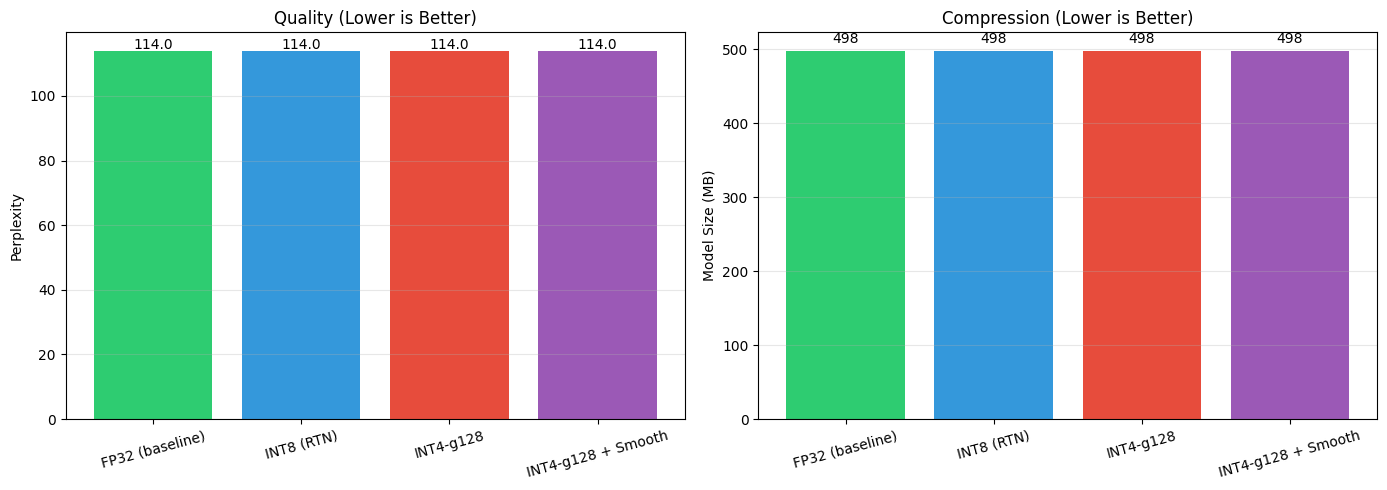

In [26]:
# Visualize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

# Perplexity
ax = axes[0]
ppls = [results[n]['perplexity'] for n in names]
bars = ax.bar(names, ppls, color=colors)
ax.set_ylabel('Perplexity')
ax.set_title('Quality (Lower is Better)')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
for bar, ppl in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, ppl + 0.5, f'{ppl:.1f}', ha='center')

# Size
ax = axes[1]
sizes = [results[n]['size_mb'] for n in names]
bars = ax.bar(names, sizes, color=colors)
ax.set_ylabel('Model Size (MB)')
ax.set_title('Compression (Lower is Better)')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, size + 10, f'{size:.0f}', ha='center')

plt.tight_layout()
plt.savefig('ptq_comparison.png', dpi=150, bbox_inches='tight')
plt.show()